baca file


In [183]:
import pandas as pd

#Membuat data frame untuk membaca data
df = pd.read_csv('../data/dataset_satelit.csv', sep=',')
df.head() # mengambil 5 baris data dari atas

,No,Longitude,Lattitude,N,P,K,Ca,Mg,Fe,Mn,...,b1,Sigma_VV,Sigma_VH,plia,lia,iafe,gamma0_vv,gamma0_vh,beta0_vv,beta0_vh
0,1,103.036658,-0.604417,2.64,0.15,0.415,0.51,0.31,119.96,463.23,...,0.0433,0.18183,0.04461,35.74446,35.79744,35.41161,0.22331,0.05479,0.31325,0.07686
1,2,103.037201,-0.604689,2.75,0.17,0.568,0.76,0.58,102.63,493.81,...,0.0465,0.22079,0.04640,35.12096,35.14591,35.41510,0.27116,0.05699,0.38033,0.07993
2,3,103.036359,-0.603012,1.77,0.12,0.339,0.49,0.6,107.37,460.93,...,0.0417,0.18926,0.03992,35.07724,35.07730,35.41135,0.23242,0.04902,0.32604,0.06876
3,4,103.036950,-0.603219,2.30,0.15,0.460,0.74,0.67,96.02,338.17,...,0.0367,0.14769,0.03622,36.08078,36.08469,35.41583,0.18138,0.04448,0.25440,0.06238
4,5,103.036802,-0.601969,2.05,0.14,0.308,0.64,0.72,87.01,384.33,...,0.0361,0.18205,0.03797,32.68855,32.69293,35.41592,0.22359,0.04664,0.31359,0.06541


In [184]:
df.describe()

,No,Longitude,Lattitude,N,P,K,Ca,Fe,Mn,Cu,...,b1,Sigma_VV,Sigma_VH,plia,lia,iafe,gamma0_vv,gamma0_vh,beta0_vv,beta0_vh
count,594.000000,594.000000,594.000000,594.000000,594.000000,593.000000,594.000000,594.000000,594.000000,594.000000,...,594.000000,594.000000,594.000000,594.000000,594.000000,594.000000,594.000000,594.000000,594.000000,594.000000
mean,297.500000,106.878644,-1.024933,2.259091,0.141380,0.582175,0.595094,74.613771,308.034697,2.391195,...,0.177291,0.234474,0.102789,28.640422,28.664891,28.609569,0.202587,0.051524,0.269642,0.062320
std,171.617307,4.949840,0.965349,0.395499,0.019782,0.222567,0.366118,55.579655,241.731643,1.580296,...,0.155615,0.070516,0.112310,15.325347,15.380384,15.329170,0.104357,0.012959,0.143728,0.024218
min,1.000000,102.760857,-2.333750,1.140000,0.090000,0.122000,0.050000,21.080000,3.160000,0.090000,...,0.014100,0.115170,0.021460,0.127000,0.098600,0.026000,0.008700,0.016900,0.009300,0.016300
25%,149.250000,102.927811,-2.233338,1.982500,0.130000,0.429000,0.320000,40.705000,124.015000,1.172500,...,0.046925,0.183210,0.039535,31.959745,31.968948,33.685353,0.183085,0.040250,0.244935,0.052772
50%,297.500000,103.581969,-0.602276,2.280000,0.140000,0.549000,0.540000,65.650000,239.445000,2.225000,...,0.072700,0.213385,0.046550,35.067930,35.110415,34.611565,0.233590,0.050415,0.310380,0.068380
75%,445.750000,113.403797,-0.257349,2.570000,0.150000,0.710000,0.790000,87.372500,434.990000,3.357500,...,0.318900,0.262242,0.059190,38.319135,38.441065,39.002760,0.271790,0.060410,0.364505,0.079020
max,594.000000,113.434700,0.069251,3.230000,0.220000,1.489000,2.820000,559.100000,2009.320000,8.170000,...,0.751400,0.512210,0.373000,47.592900,48.014640,39.209330,0.658960,0.122300,0.814170,0.150620


In [185]:
# pilih 2 variabel utama dari dataset
df1 = (df[["N", "P", "Fe"]]
       .rename(columns={
           "N": "nitrogen",
           "P": "fosfor"
       }).copy())

# transformasi: ubah satuan ke mg/kg (misalnya dari % ke mg/kg)
df1["nitrogen_mgkg"] = df1["nitrogen"] * 10000
df1["fosfor_mgkg"] = df1["fosfor"] * 10000

# tampilkan 5 data pertama
df1.head()


,nitrogen,fosfor,Fe,nitrogen_mgkg,fosfor_mgkg
0,2.64,0.15,119.96,26400.0,1500.0
1,2.75,0.17,102.63,27500.0,1700.0
2,1.77,0.12,107.37,17700.0,1200.0
3,2.30,0.15,96.02,23000.0,1500.0
4,2.05,0.14,87.01,20500.0,1400.0


In [186]:
x = df[["N"]]     # variabel independen (fitur)
y = df[["P", "Fe"]]     # variabel dependen (target)

# 2️⃣ Split data menjadi data latih dan uji (80:20)
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=7
)

In [187]:
from sklearn.linear_model import LinearRegression
#Buat object model instan dari class Linear Regression
model = LinearRegression()
#Lakukan proses training
model.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [188]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Buat model regresi linear
model = LinearRegression()
model.fit(x_train, y_train)

# Prediksi
y_pred = model.predict(x_test)

# Evaluasi model
r2 = r2_score(y_test, y_pred, multioutput='raw_values')

print("Koefisien (pengaruh N terhadap P dan Fe):", model.coef_[0])
print("Intersep:", model.intercept_)
print("R2 (test):", r2)
print("MAE:", mean_absolute_error(y_test, y_pred))
mse = mean_squared_error(y_test, y_pred)  # default squared=True
rmse = np.sqrt(mse)
print("RMSE:", rmse)


Koefisien (pengaruh N terhadap P dan Fe): [0.03276132]
Intersep: [  0.06718958 -37.32870823]
R2 (test): [0.44908407 0.04419325]
MAE: 11.239037781534394
RMSE: 19.550427862097845


In [189]:
slope = model.coef_[0][0]
intercept = model.intercept_[0]
print(f"Persamaan: y = {slope:.3f} * x + {intercept:.3f}")

Persamaan: y = 0.033 * x + 0.067


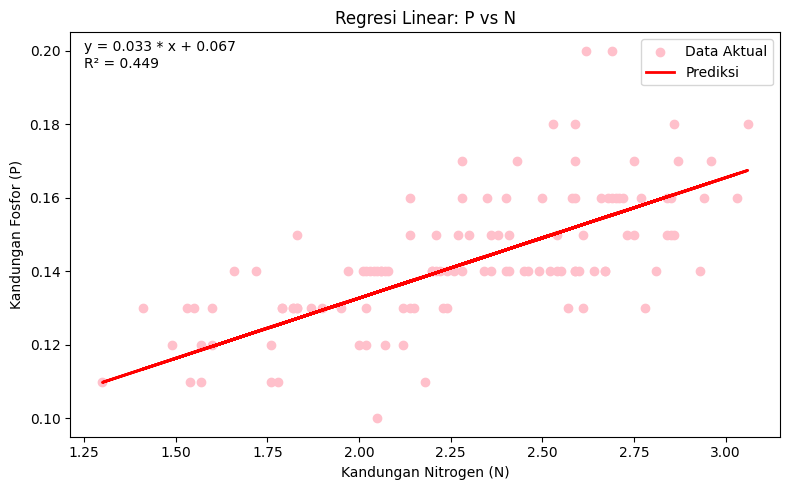

In [190]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# --- Data ---
x = df[["N"]]     # variabel independen
y = df[["P"]]     # target

# --- Split data ---
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=7
)

# --- Model ---
model = LinearRegression()
model.fit(x_train, y_train)

# --- Prediksi ---
y_pred = model.predict(x_test)

# --- Evaluasi ---
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)

# --- Ambil koefisien dan intersep ---
slope = model.coef_[0][0]
intercept = model.intercept_[0]

# --- Plot ---
plt.figure(figsize=(8, 5))
plt.scatter(x_test, y_test, color="pink", label="Data Aktual")
plt.plot(x_test, y_pred, color="red", linewidth=2, label="Prediksi")

plt.xlabel("Kandungan Nitrogen (N)")
plt.ylabel("Kandungan Fosfor (P)")
plt.title("Regresi Linear: P vs N")

plt.text(
    0.02, 0.98,
    f"y = {slope:.3f} * x + {intercept:.3f}\nR² = {r2:.3f}",
    transform=plt.gca().transAxes,
    va="top"
)

plt.legend()
plt.tight_layout()
plt.show()


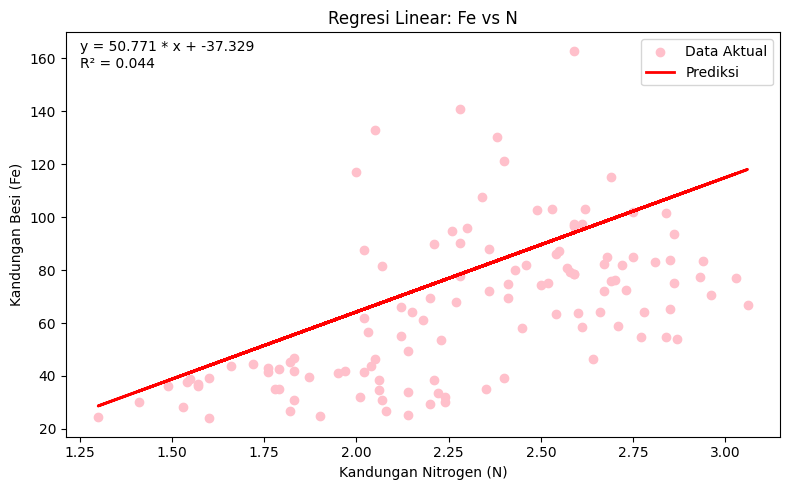

In [191]:
# --- Data ---
x = df[["N"]]
y = df[["Fe"]]

# --- Split data ---
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=7
)

# --- Model ---
model = LinearRegression()
model.fit(x_train, y_train)

# --- Prediksi ---
y_pred = model.predict(x_test)

# --- Evaluasi ---
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)

# --- Ambil koefisien dan intersep ---
slope = model.coef_[0][0]
intercept = model.intercept_[0]

# --- Plot ---
plt.figure(figsize=(8, 5))
plt.scatter(x_test, y_test, color="pink", label="Data Aktual")
plt.plot(x_test, y_pred, color="red", linewidth=2, label="Prediksi")

plt.xlabel("Kandungan Nitrogen (N)")
plt.ylabel("Kandungan Besi (Fe)")
plt.title("Regresi Linear: Fe vs N")

plt.text(
    0.02, 0.98,
    f"y = {slope:.3f} * x + {intercept:.3f}\nR² = {r2:.3f}",
    transform=plt.gca().transAxes,
    va="top"
)

plt.legend()
plt.tight_layout()
plt.show()


In [192]:
# Hitung matriks korelasi
corr_matrix = df1.corr()

print(corr_matrix)


               nitrogen    fosfor        Fe  nitrogen_mgkg  fosfor_mgkg
nitrogen       1.000000  0.643212  0.338775       1.000000     0.643212
fosfor         0.643212  1.000000  0.214960       0.643212     1.000000
Fe             0.338775  0.214960  1.000000       0.338775     0.214960
nitrogen_mgkg  1.000000  0.643212  0.338775       1.000000     0.643212
fosfor_mgkg    0.643212  1.000000  0.214960       0.643212     1.000000


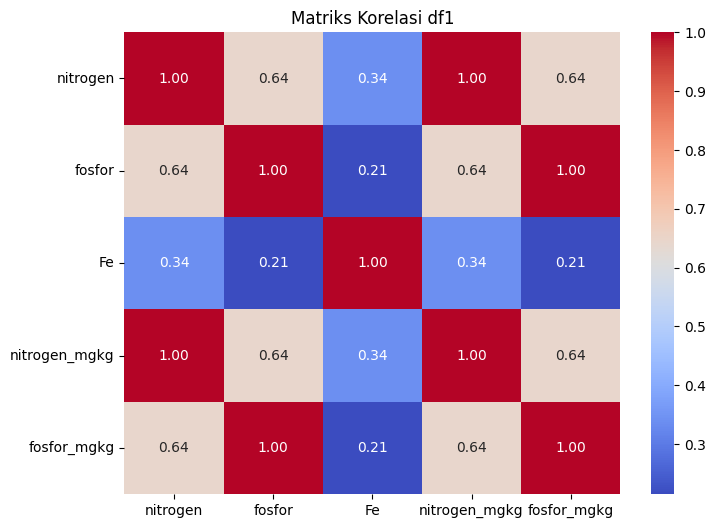

In [193]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriks Korelasi df1")
plt.show()


In [194]:
from sklearn.model_selection import train_test_split

# Misalkan target (Y) adalah intensitas Sigma_VV, # Variabel dependen
y = df["P"]

# Fitur (X) adalah kandungan Fe dan Ca, # Variabel independen
X = df[["N", "Fe"]]

# Bagi data 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42  # random_state supaya hasil konsisten
)

## Cetak Pembagian Data
print("Jumlah data train :", len(X_train))
print("Jumlah data test  :", len(X_test))

## cek apakah sudah ada constanta pada data training
X_train.head()


Jumlah data train : 475
Jumlah data test  : 119


,N,Fe
155,2.00,117.01
550,2.61,86.69
132,2.62,103.11
450,2.31,38.89
287,2.25,42.41


In [195]:
import statsmodels.api as sm

# lalu:
X_train_const = sm.add_constant(X_train)
X_train_const.head()

,const,N,Fe
155,1.0,2.00,117.01
550,1.0,2.61,86.69
132,1.0,2.62,103.11
450,1.0,2.31,38.89
287,1.0,2.25,42.41


In [196]:
import statsmodels.api as sm

# Tambahkan konstanta ke data training
X_train_const = sm.add_constant(X_train)

# Buat model OLS
model = sm.OLS(y_train, X_train_const).fit()
print('-------------------------------')
print(model.params)
print('-------------------------------')

const = model.params['const']
x1_Fe = model.params['Fe']
x2_N = model.params['N']

# print persamaan regresi
print(f"y = {const:.3f} + {x1_Fe:.3f}*x1 + {x2_N:.3f}*x2")


-------------------------------
const    0.064225
N        0.033820
Fe       0.000005
dtype: float64
-------------------------------
y = 0.064 + 0.000*x1 + 0.034*x2


In [197]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      P   R-squared:                       0.455
Model:                            OLS   Adj. R-squared:                  0.453
Method:                 Least Squares   F-statistic:                     197.2
Date:                Sun, 09 Nov 2025   Prob (F-statistic):           5.55e-63
Time:                        21:22:58   Log-Likelihood:                 1329.7
No. Observations:                 475   AIC:                            -2653.
Df Residuals:                     472   BIC:                            -2641.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0642      0.004     16.338      0.0

In [198]:
import numpy as np  # ← tambahkan ini di awal

# Tambahkan konstanta ke data uji
X_test_const = sm.add_constant(X_test)

# Prediksi Sigma_VV
y_pred_test = model.predict(X_test_const)

# Buat tabel hasil prediksi
hasil = pd.DataFrame({
    "Fe": X_test["Fe"].to_numpy(),
    "Ca": X_test["N"].to_numpy(),
    "Sigma_VV Aktual": y_test.to_numpy(),
    "Sigma_VV Prediksi": y_pred_test
})

# 1) Selisih error (positif = overpredict)
hasil["Selisih error"] = hasil["Sigma_VV Prediksi"] - hasil["Sigma_VV Aktual"]

# 2) Akurasi per-baris (100 × (1 − |error/aktual|)), dibatasi 0–100
denom = hasil["Sigma_VV Aktual"].replace(0, np.nan)  # antisipasi pembagi nol
hasil["Akurasi (%)"] = (1 - (hasil["Selisih error"].abs() / denom)).clip(lower=0, upper=1) * 100

hasil


,Fe,Ca,Sigma_VV Aktual,Sigma_VV Prediksi,Selisih error,Akurasi (%)
30,115.31,2.69,0.20,0.155722,-0.044278,77.861118
299,40.23,2.28,0.17,0.141517,-0.028483,83.245416
177,138.32,2.48,0.14,0.148724,0.008724,93.768745
204,64.29,2.66,0.16,0.154477,-0.005523,96.548423
354,45.72,2.46,0.16,0.147630,-0.012370,92.268523
...,...,...,...,...,...,...
580,74.56,2.60,0.16,0.152495,-0.007505,95.309114
228,88.02,2.36,0.14,0.144438,0.004438,96.829704
84,105.57,2.51,0.17,0.149591,-0.020409,87.994491
140,89.80,2.21,0.14,0.139373,-0.000627,99.552421
